In [1]:
# 必要ライブラリのインポート
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.load import load_jsonl
from utils.load import flatten


In [2]:
# データ読み込みとDataFrame化
data = load_jsonl("../data/dataset.jsonl")
df = flatten(data)

print(f"✅ {len(df)} 件の評価が読み込まれました")
df.head()


✅ 5640 件の評価が読み込まれました


,original_id,simplified_id,model_name,original_text,simplified_text,evaluator_id,necessity,sufficiency,sentence_simplicity,document_simplicity
0,1,1,bart,北越急行ほくほく線\nほくほく線（ほくほくせん）は、新潟県南魚沼市の六日町駅から、同県上越市...,新潟県南魚沼市の六日町駅から、同県上越市の犀潟(さいがたえき)までを結ぶ北越急行の鉄道路線で...,1,0,2,2,3
1,1,1,bart,北越急行ほくほく線\nほくほく線（ほくほくせん）は、新潟県南魚沼市の六日町駅から、同県上越市...,新潟県南魚沼市の六日町駅から、同県上越市の犀潟(さいがたえき)までを結ぶ北越急行の鉄道路線で...,2,1,3,3,3
2,1,1,bart,北越急行ほくほく線\nほくほく線（ほくほくせん）は、新潟県南魚沼市の六日町駅から、同県上越市...,新潟県南魚沼市の六日町駅から、同県上越市の犀潟(さいがたえき)までを結ぶ北越急行の鉄道路線で...,3,0,2,2,3
3,1,1,bart,北越急行ほくほく線\nほくほく線（ほくほくせん）は、新潟県南魚沼市の六日町駅から、同県上越市...,新潟県南魚沼市の六日町駅から、同県上越市の犀潟(さいがたえき)までを結ぶ北越急行の鉄道路線で...,4,1,2,3,3
4,1,1,bart,北越急行ほくほく線\nほくほく線（ほくほくせん）は、新潟県南魚沼市の六日町駅から、同県上越市...,新潟県南魚沼市の六日町駅から、同県上越市の犀潟(さいがたえき)までを結ぶ北越急行の鉄道路線で...,5,1,2,1,2


In [3]:
# モデルごとの平均スコアを表示
score_cols = ["necessity", "sufficiency", "sentence_simplicity", "document_simplicity"]
df.groupby("model_name")[score_cols].mean().round(2)


,necessity,sufficiency,sentence_simplicity,document_simplicity
model_name,,,,
GPT-4o_0-shot,0.89,2.57,2.86,2.88
GPT-4o_1-shot,0.93,2.74,2.73,2.82
JADOS_target,0.72,2.30,2.22,2.65
Llama-swallow,0.86,2.67,2.44,2.68
bart,0.77,2.26,2.14,2.60
gemma,0.69,2.22,2.82,2.86


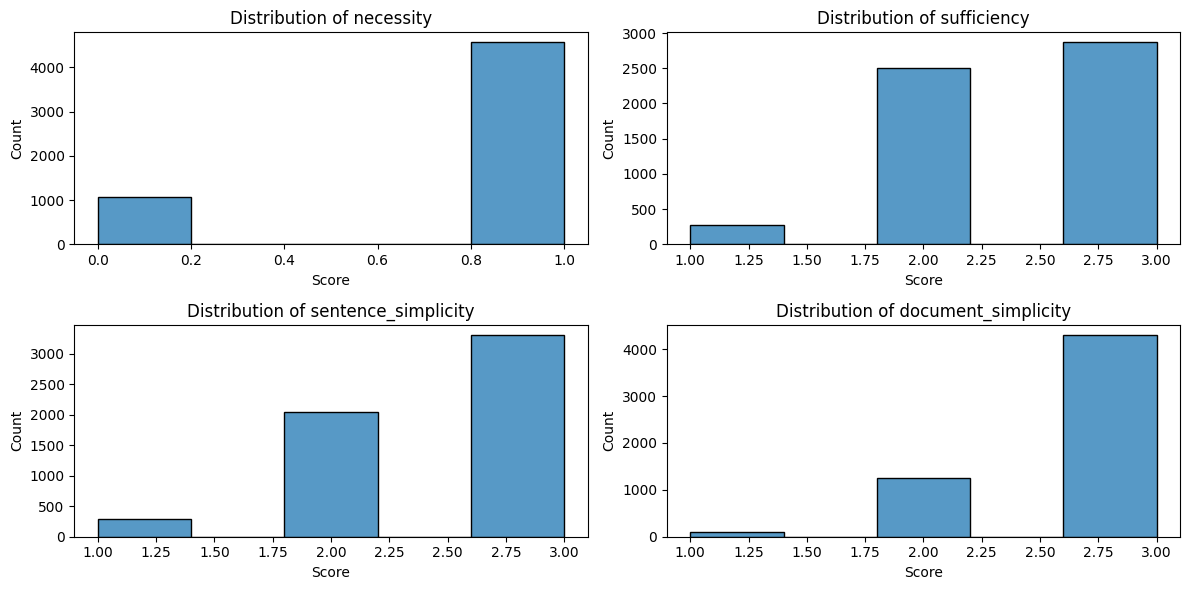

In [4]:
# 評価観点ごとのスコア分布をヒストグラムで表示
plt.figure(figsize=(12, 6))
for i, col in enumerate(score_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=5, kde=False)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Score")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
#圧縮率とスコアの関係を散布図で確認（任意）
df["original_length"] = df["original_text"].str.len()
df["simplified_length"] = df["simplified_text"].str.len()
df["compression_ratio"] = df["simplified_length"] / df["original_length"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="compression_ratio", y="sentence_simplicity", hue="model_name")
plt.title("Compression Ratio vs Sentence Simplicity")
plt.grid(True)
plt.show()
